In [2]:
#ÉTAPE 1 : Chargement + exploration initiale
       #1. Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#2. Chargement des données
df = pd.read_csv("/home/chris/Téléchargements/archive (5)/loan_risk_prediction_dataset.csv") # adapte le chemin
df.head(10)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0
5,25,47886.0,18106.0,835.0,13,Male,Masters,New York,Salaried,1
6,38,54748.0,25374.0,760.0,9,Female,High School,New York,Self-Employed,1
7,56,NaN,6279.0,599.0,22,Male,PhD,New York,Unemployed,0
8,36,25918.0,25041.0,777.0,29,Female,Bachelors,San Francisco,Unemployed,0
9,40,43415.0,2065.0,382.0,30,Female,High School,San Francisco,Self-Employed,0


In [4]:
#Comprendre les colonnes
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   str    
 6   Education        4802 non-null   str    
 7   City             5000 non-null   str    
 8   EmploymentType   5000 non-null   str    
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 390.8 KB


Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved'],
      dtype='str')

In [5]:
df.shape

(5000, 10)

In [6]:
#Vérifie le déséquilibre :
df["LoanApproved"].value_counts()

LoanApproved
0    3849
1    1151
Name: count, dtype: int64

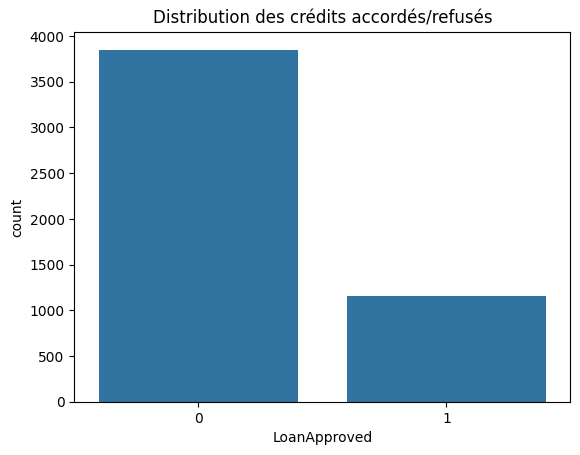

In [7]:
sns.countplot(x="LoanApproved", data=df)
plt.title("Distribution des crédits accordés/refusés")
plt.show()

In [ ]:
                        #INTERPRÉTATION#
""""La variable cible "LoanApproved" est déséquilibrée : environ 77% des crédits sont refusés contre 23% acceptés.

Ce déséquilibre peut influencer les performances du modèle, qui pourrait privilégier la classe majoritaire.

Il sera donc important d’utiliser des métriques adaptées comme le recall, la precision et la matrice de confusion."""

In [11]:
#Étape 2 : Prétraitement des données.
#1. Vérifier les valeurs manquantes

#df.isnull().sum()

In [12]:
#2. Traitement des valeurs manquantes
df["Education"] = df["Education"].fillna(df["Education"].mode()[0])

In [13]:
#Vérifier les valeurs manquantes
df.isnull().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education            0
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [ ]:
"""Les valeurs manquantes ont été traitées afin d’éviter la perte d’information.

Les variables numériques ont été imputées par la moyenne, tandis que la variable catégorielle Education a été complétée par le mode."""

In [14]:
#3. Encodage des variables catégorielles
df = pd.get_dummies(df, drop_first=True)

In [15]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved,Gender_Male,Education_High School,Education_Masters,Education_PhD,City_Houston,City_New York,City_San Francisco,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56,48353.0,31258.0,675.0,20,0,False,True,False,False,True,False,False,False,True
1,69,57462.0,23262.0,586.0,6,0,True,True,False,False,False,False,True,True,False
2,46,44219.0,26530.0,781.0,26,1,True,False,False,True,True,False,False,True,False
3,32,56307.0,11531.0,549.0,11,0,True,False,False,False,False,True,False,False,True
4,60,37034.0,27871.0,500.0,19,0,False,True,False,False,False,False,False,False,True


In [16]:
#Séparer X et y
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]


In [17]:
print(X.shape)
print(y.shape)

(5000, 14)
(5000,)


In [ ]:
"""Les valeurs manquantes ont été traitées par imputation :

- médiane pour les variables numériques
- mode pour les variables catégorielles

Les variables catégorielles ont été encodées en variables binaires afin d’être compatibles avec les algorithmes de Machine Learning.

Cette étape garantit une préparation propre des données avant la modélisation."""

In [18]:
#Étape 3 : Split + préparation des données pour le modèle.
  #1. Split des données
    
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
#Vérification
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(4000, 14) (1000, 14)
LoanApproved
0    0.76975
1    0.23025
Name: proportion, dtype: float64
LoanApproved
0    0.77
1    0.23
Name: proportion, dtype: float64


In [ ]:
"""Les données ont été séparées en ensembles d’entraînement et de test (80/20).
La stratification a été utilisée pour conserver la distribution des classes."""

In [20]:
#2. Normalisation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

num_cols = ["Age", "Income", "LoanAmount", "CreditScore", "YearsExperience"]

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
"""Les variables numériques ont été normalisées afin d’améliorer les performances du modèle, notamment pour la régression logistique."""

In [25]:
X_train_scaled = X_train_scaled.fillna(0)
X_test_scaled = X_test_scaled.fillna(0)

In [26]:
X_train_scaled.isnull().sum()

Age                             0
Income                          0
LoanAmount                      0
CreditScore                     0
YearsExperience                 0
Gender_Male                     0
Education_High School           0
Education_Masters               0
Education_PhD                   0
City_Houston                    0
City_New York                   0
City_San Francisco              0
EmploymentType_Self-Employed    0
EmploymentType_Unemployed       0
dtype: int64

In [27]:
#ÉTAPE 4 : Modélisation + Évaluation

#1. Modèle principal (LOGISTIC REGRESSION)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
#2. Prédictions
y_pred = model.predict(X_test_scaled)

In [30]:
#3. Evaluation
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93       770
           1       0.78      0.70      0.73       230

    accuracy                           0.88      1000
   macro avg       0.84      0.82      0.83      1000
weighted avg       0.88      0.88      0.88      1000



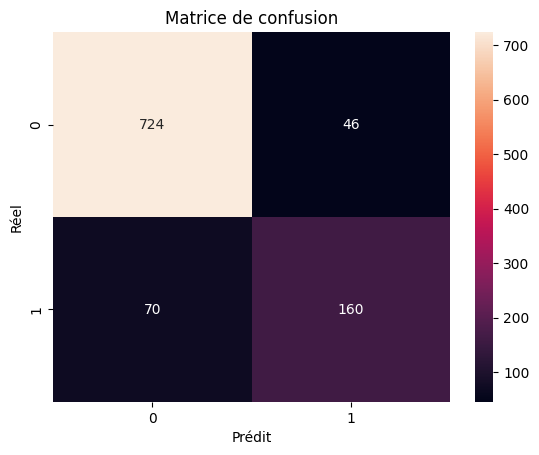

In [42]:
#4. Matrice de confusion
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.savefig("confusion_matrix.png")  # 🔥 enregistre l'image
plt.show()

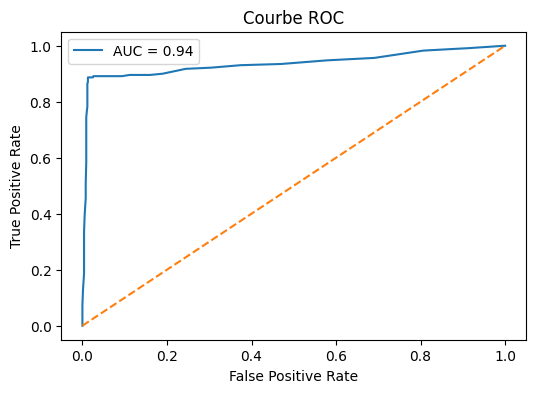

In [43]:
#5- Courbe ROC
from sklearn.metrics import roc_curve, auc

y_proba = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],"--")

plt.title("Courbe ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("roc_curve.png")  # 🔥 enregistre
plt.show()

In [33]:
"""Le modèle présente de bonnes performances globales avec une accuracy de 88%.

Cependant, le recall pour la classe 1 (clients acceptés) est de 70%, ce qui signifie qu'une partie des bons clients est mal classée.

Dans un contexte bancaire, cela peut entraîner une perte d'opportunités, car des clients solvables pourraient se voir refuser un crédit.

Une amélioration du modèle est donc nécessaire afin d’augmenter la détection des clients à accepter."""

"Le modèle présente de bonnes performances globales avec une accuracy de 88%.\n\nCependant, le recall pour la classe 1 (clients acceptés) est de 70%, ce qui signifie qu'une partie des bons clients est mal classée.\n\nDans un contexte bancaire, cela peut entraîner une perte d'opportunités, car des clients solvables pourraient se voir refuser un crédit.\n\nUne amélioration du modèle est donc nécessaire afin d’augmenter la détection des clients à accepter."

In [35]:
#AMÉLIORATION PERFORMANCE DU MODELE
#1. Ajuster le seuil

y_proba = model.predict_proba(X_test_scaled)[:,1]

y_pred_custom = (y_proba > 0.4).astype(int)

In [36]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       770
           1       0.73      0.78      0.75       230

    accuracy                           0.88      1000
   macro avg       0.83      0.85      0.84      1000
weighted avg       0.89      0.88      0.88      1000



In [38]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       770
           1       0.95      0.89      0.92       230

    accuracy                           0.96      1000
   macro avg       0.96      0.94      0.95      1000
weighted avg       0.96      0.96      0.96      1000



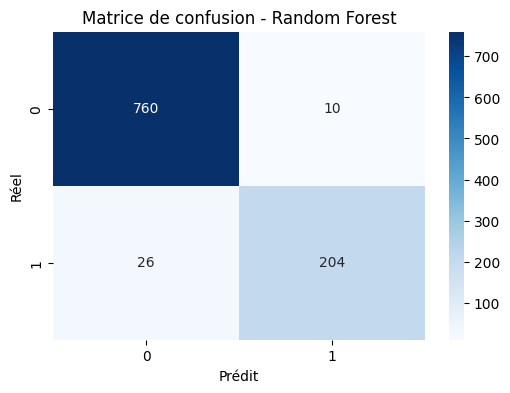

In [44]:
#Matrice de confusion Random Forest
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Prédictions Random Forest
y_pred_rf = rf.predict(X_test)

# 🔹 Matrice de confusion
cm = confusion_matrix(y_test, y_pred_rf)

# 🔹 Affichage
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matrice de confusion - Random Forest")
plt.xlabel("Prédit")
plt.ylabel("Réel")

plt.show()

In [ ]:
          #ANALYSE 
    
    """
Classe 1 (clients acceptés):

          -Precision = 95%
          -Recall =  89% 
          -F1-score = 92%
          
          Traduction : Le modèle détecte 89% des clients à accepter (recall) avec une précision de 95%.
        
                                                 
Classe 0 (refus):

       -Recall = 99%
       
       Traduction: Le modèle détecte presque tous les mauvais clients.

Conclusion :

 Nous avons un modèle est très performant et équilibré

"""

In [ ]:
#INTERPRÉTATION MÉTIER

""" 
Le modèle Random Forest présente d’excellentes performances avec une forte capacité à identifier les clients solvables (recall de 89%) tout en limitant les erreurs (precision de 95%).

Cela signifie que peu de clients à risque sont acceptés et que la majorité des bons clients sont correctement identifiés, ce qui est crucial dans un contexte bancaire.


"""

In [ ]:
#COMPARAISON

"""
| Modèle              | Recall classe 1 |
| ------------------- | --------------- |
| Logistic Regression | 70% ❌           |
| Random Forest       | 89% 🔥          |


Random Forest est plus performant pour ce problème


"""

In [39]:
#Étape 5 : Interprétation du modèle

#1. Feature Importance

import pandas as pd

importances = rf.feature_importances_

features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.head(10)

CreditScore                     0.448574
Income                          0.194811
EmploymentType_Unemployed       0.172524
LoanAmount                      0.049440
Age                             0.039843
YearsExperience                 0.037132
EmploymentType_Self-Employed    0.023105
Gender_Male                     0.005852
Education_PhD                   0.005231
City_New York                   0.005078
dtype: float64

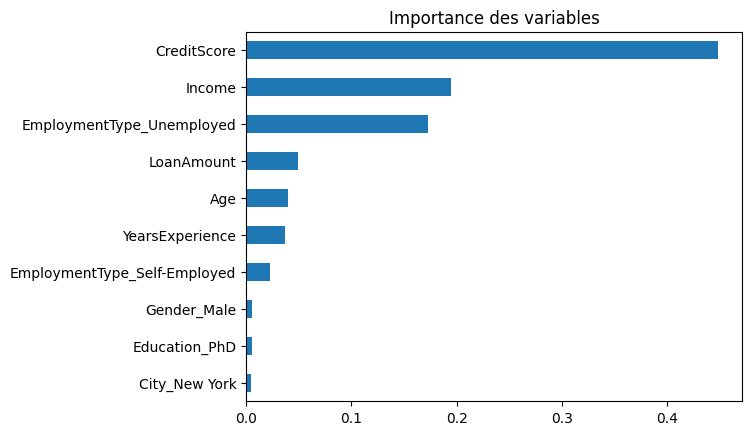

In [40]:
#2. Visualisation
import matplotlib.pyplot as plt

feat_imp.head(10).plot(kind='barh')
plt.title("Importance des variables")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
'''
Les variables les plus importantes pour la décision du modèle sont :

- CreditScore
- Income
- LoanAmount
- YearsExperience

Cela montre que le modèle se base principalement sur la capacité financière et la stabilité du client pour accorder un crédit.
'''

In [ ]:
                   #ANALYSE MÉTIER
    
'''
Un score de crédit élevé augmente la probabilité d’acceptation du crédit.

Un revenu élevé et une expérience professionnelle importante réduisent le risque de défaut.

Un montant de prêt élevé peut augmenter le risque, ce qui influence la décision du modèle.
'''


In [41]:
                           #CONCLUSION DU PROJET

'''
Ce projet démontre l’utilisation du Machine Learning pour résoudre un problème réel de scoring de crédit.

Le modèle Random Forest a montré de meilleures performances que la régression logistique, notamment dans la détection des clients solvables.

L’analyse des variables permet de comprendre les facteurs clés influençant les décisions, ce qui est essentiel dans un contexte financier.
'''